# **AI Prediction**

In [25]:
import pandas as pd
import numpy as np

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
df = pd.read_excel("/content/drive/MyDrive/Data Mining/Data/Overall Data.xlsx")
df.head()

,No.,Gender,Age (Month),Weight,Height,Weight for Age,Z-Score W/A,Height for Age,Z-Score H/A,Weight for Height,Z-Score W/H
0,1,F,54.0,13.2,97.5,Normal,-1.94,Stunted,-2.11,Normal,-0.95
1,2,M,44.0,12,92.0,Normal,-1.92,Stunted,-2.22,Normal,-0.88
2,3,M,57.0,14,97.0,Normal,-1.9,Stunted,-2.58,Normal,-0.48
3,4,M,26.0,11,79.0,Normal,-1.15,Stunted,-3.11,Normal,0.68
4,5,F,59.0,14.6,98.0,Normal,-1.66,Stunted,-2.49,Normal,-0.18


In [28]:
# PILIH KOLOM YANG DIGUNAKAN

df = df[
    [
        'Gender',
        'Age (Month)',
        'Weight',
        'Height',
        'Height for Age'
    ]
].copy()

df.head()

,Gender,Age (Month),Weight,Height,Height for Age
0,F,54.0,13.2,97.5,Stunted
1,M,44.0,12,92.0,Stunted
2,M,57.0,14,97.0,Stunted
3,M,26.0,11,79.0,Stunted
4,F,59.0,14.6,98.0,Stunted


# TAHAP 2 — DATA UNDERSTANDING

In [29]:
# INFORMASI DATASET

print("Jumlah Data :", df.shape[0])
print("Jumlah Kolom:", df.shape[1])

print("\nNama Kolom:")
print(df.columns)

Jumlah Data : 40071
Jumlah Kolom: 5

Nama Kolom:
Index(['Gender', 'Age (Month)', 'Weight', 'Height', 'Height for Age'], dtype='object')


In [30]:
# TIPE DATA

df.dtypes

,0
Gender,object
Age (Month),float64
Weight,object
Height,float64
Height for Age,object


In [31]:
#Ubah tipe data weight
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')

print(df.dtypes)

Gender             object
Age (Month)       float64
Weight            float64
Height            float64
Height for Age     object
dtype: object


In [32]:
# MISSING VALUE

df.isnull().sum()

,0
Gender,0
Age (Month),2
Weight,20158
Height,0
Height for Age,0


In [33]:
# DISTRIBUSI TARGET
#Distribusi Height for Age

df["Height for Age"].value_counts()

,count
Height for Age,
Not Stunted,23867
Stunted,16204


In [34]:
# PERSENTASE DISTRIBUSI

df["Height for Age"].value_counts(normalize=True)*100

,proportion
Height for Age,
Not Stunted,59.561778
Stunted,40.438222


# TAHAP 3 — DATA PREPARATION

In [35]:
# MEMILIH FITUR DAN TARGET

df = df[
    [
        'Gender',
        'Age (Month)',
        'Weight',
        'Height',
        'Height for Age'
    ]
]

In [36]:
# HAPUS DATA KOSONG

df = df.dropna()
df.shape

(19912, 5)

In [37]:
#Encoding Gender

from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()

df['Gender'] = gender_encoder.fit_transform(df['Gender'])

print(df.head())

   Gender  Age (Month)  Weight  Height Height for Age
0       0         54.0    13.2    97.5        Stunted
1       1         44.0    12.0    92.0        Stunted
2       1         57.0    14.0    97.0        Stunted
3       1         26.0    11.0    79.0        Stunted
4       0         59.0    14.6    98.0        Stunted


In [38]:
#Encoding Target
#Not Stunted = 0
#Stunted     = 1

target_encoder = LabelEncoder()

df['Height for Age'] = target_encoder.fit_transform(
    df['Height for Age']
)

print(df['Height for Age'].value_counts())

Height for Age
1    13183
0     6729
Name: count, dtype: int64


In [39]:
#Pisahkan X dan y
X = df[
    [
        'Gender',
        'Age (Month)',
        'Weight',
        'Height'
    ]
]

y = df['Height for Age']

print(X.shape)
print(y.shape)

(19912, 4)
(19912,)


In [40]:
#Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Training :", X_train.shape)
print("Data Testing  :", X_test.shape)

Data Training : (15929, 4)
Data Testing  : (3983, 4)


In [41]:
print(X_train.shape)
print(X_test.shape)

print(y.value_counts())

(15929, 4)
(3983, 4)
Height for Age
1    13183
0     6729
Name: count, dtype: int64


# TAHAP 4 - MODELING (Random Forest)

In [85]:
#Training Random Forest

import joblib
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

joblib.dump(rf, "model_stunting.pkl")

print("Model berhasil disimpan")

Model berhasil disimpan


In [43]:
# Prediksi Data Testing

y_pred = rf.predict(X_test)

# TAHAP 5 - EVALUASI MODEL

In [44]:
# Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 93.55 %


In [45]:
#Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.83      0.90      1346
           1       0.92      0.99      0.95      2637

    accuracy                           0.94      3983
   macro avg       0.95      0.91      0.93      3983
weighted avg       0.94      0.94      0.93      3983



[[1119  227]
 [  30 2607]]


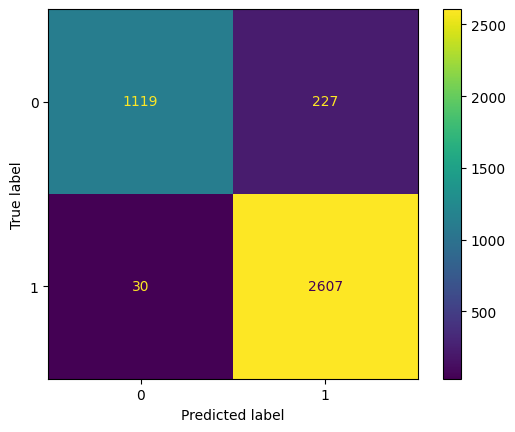

In [46]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

# TAHAP 6 - FEATURE IMPORTANCE



In [47]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

       Feature  Importance
3       Height    0.443780
2       Weight    0.279920
1  Age (Month)    0.263542
0       Gender    0.012758


In [88]:
#fungsi AI

import numpy as np

def predict_stunting(gender, age_month, weight, height, model):

    gender_encoded = 1 if gender == "Male" else 0

    data = np.array([
        [gender_encoded, age_month, weight, height]
    ])

    prediction = model.predict(data)[0]

    probability = model.predict_proba(data)[0]

    confidence = round(max(probability) * 100, 2)

    status = "Stunted" if prediction == 1 else "Not Stunted"

    return status, confidence

In [89]:
#uji coba

status, confidence = predict_stunting(
    gender="Male",
    age_month=24,
    weight=10,
    height=80,
    model=rf
)

print("Status :", status)
print("Confidence :", confidence, "%")

Status : Stunted
Confidence : 70.81 %


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [90]:
import joblib

joblib.dump(rf, "model_stunting.pkl")

print("Model berhasil disimpan")

Model berhasil disimpan


In [91]:
from google.colab import files

files.download("model_stunting.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **WHO Prediction**

In [52]:
!pip install openpyxl

In [49]:
from google.colab import files

uploaded = files.upload()

Saving wfh_boys_2-to-5-years_zscores.zip to wfh_boys_2-to-5-years_zscores.zip


In [50]:
#Extract ZIP
import zipfile
import os

zip_path = "wfh_boys_2-to-5-years_zscores.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("who_data")

print("Berhasil diekstrak")

Berhasil diekstrak


In [51]:
import os

for file in os.listdir("who_data"):
    print(file)

lhfa_boys_0-to-2-years_zscores.xlsx
lhfa_boys_2-to-5-years_zscores.xlsx
lhfa_girls_0-to-2-years_zscores.xlsx
lhfa_girls_2-to-5-years_zscores.xlsx
wfh_boys_2-to-5-years_zscores.xlsx
wfa_boys_0-to-5-years_zscores.xlsx
wfa_girls_0-to-5-years_zscores.xlsx
wfh_girls_2-to-5-years_zscores.xlsx


In [53]:
import pandas as pd

haz_boys_0_2 = pd.read_excel(
    "who_data/lhfa_boys_0-to-2-years_zscores.xlsx"
)

haz_boys_0_2.head()

,Month,L,M,S,SD,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3
0,0,1,49.8842,0.03795,1.8931,44.2,46.1,48.0,49.9,51.8,53.7,55.6
1,1,1,54.7244,0.03557,1.9465,48.9,50.8,52.8,54.7,56.7,58.6,60.6
2,2,1,58.4249,0.03424,2.0005,52.4,54.4,56.4,58.4,60.4,62.4,64.4
3,3,1,61.4292,0.03328,2.0444,55.3,57.3,59.4,61.4,63.5,65.5,67.6
4,4,1,63.8860,0.03257,2.0808,57.6,59.7,61.8,63.9,66.0,68.0,70.1


In [54]:
#Cek Struktur Kolom

print(haz_boys_0_2.columns.tolist())

['Month', 'L', 'M', 'S', 'SD', 'SD3neg', 'SD2neg', 'SD1neg', 'SD0', 'SD1', 'SD2', 'SD3']


# HAZ (Height-for-Age Z-score)



In [58]:
#fungsi status (TB/U)

def get_haz_status(age_month, height_cm, haz_table):

    row = haz_table[haz_table['Month'] == age_month]

    if len(row) == 0:
        return None

    row = row.iloc[0]

    if height_cm < row['SD3neg']:
        status = "Severely Stunted"

    elif height_cm < row['SD2neg']:
        status = "Stunted"

    else:
        status = "Normal"

    return status

In [59]:
#Uji Coba

get_haz_status(
    age_month=24,
    height_cm=80,
    haz_table=haz_boys_0_2
)

'Stunted'

In [60]:
#fungsi Z-Score

def calculate_haz_zscore(age_month, height_cm, haz_table):

    row = haz_table[haz_table['Month'] == age_month]

    if len(row) == 0:
        return None

    row = row.iloc[0]

    points = [
        (row['SD3neg'], -3),
        (row['SD2neg'], -2),
        (row['SD1neg'], -1),
        (row['SD0'], 0),
        (row['SD1'], 1),
        (row['SD2'], 2),
        (row['SD3'], 3)
    ]

    for i in range(len(points)-1):

        x1, z1 = points[i]
        x2, z2 = points[i+1]

        if x1 <= height_cm <= x2:

            zscore = z1 + (
                (height_cm - x1)
                * (z2 - z1)
                / (x2 - x1)
            )

            return round(zscore, 2)

    if height_cm < row['SD3neg']:
        return -3.0

    if height_cm > row['SD3']:
        return 3.0

    return None

In [62]:
# uji coba

float(
    calculate_haz_zscore(
        age_month=24,
        height_cm=80,
        haz_table=haz_boys_0_2
    )
)

-2.57

# WAZ (Weight-for-Age)

In [63]:
waz_boys = pd.read_excel(
    "who_data/wfa_boys_0-to-5-years_zscores.xlsx"
)

waz_girls = pd.read_excel(
    "who_data/wfa_girls_0-to-5-years_zscores.xlsx"
)

In [64]:
print(waz_boys.columns.tolist())

['Month', 'L', 'M', 'S', 'SD3neg', 'SD2neg', 'SD1neg', 'SD0', 'SD1', 'SD2', 'SD3']


In [65]:
waz_boys.head()

,Month,L,M,S,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3
0,0,0.3487,3.3464,0.14602,2.1,2.5,2.9,3.3,3.9,4.4,5.0
1,1,0.2297,4.4709,0.13395,2.9,3.4,3.9,4.5,5.1,5.8,6.6
2,2,0.1970,5.5675,0.12385,3.8,4.3,4.9,5.6,6.3,7.1,8.0
3,3,0.1738,6.3762,0.11727,4.4,5.0,5.7,6.4,7.2,8.0,9.0
4,4,0.1553,7.0023,0.11316,4.9,5.6,6.2,7.0,7.8,8.7,9.7


In [66]:
#fungsi hitung

def calculate_waz_zscore(age_month, weight_kg, waz_table):

    row = waz_table[waz_table['Month'] == age_month]

    if len(row) == 0:
        return None

    row = row.iloc[0]

    points = [
        (row['SD3neg'], -3),
        (row['SD2neg'], -2),
        (row['SD1neg'], -1),
        (row['SD0'], 0),
        (row['SD1'], 1),
        (row['SD2'], 2),
        (row['SD3'], 3)
    ]

    for i in range(len(points)-1):

        x1, z1 = points[i]
        x2, z2 = points[i+1]

        if x1 <= weight_kg <= x2:

            zscore = z1 + (
                (weight_kg - x1)
                * (z2 - z1)
                / (x2 - x1)
            )

            return round(float(zscore), 2)

    if weight_kg < row['SD3neg']:
        return -3.0

    if weight_kg > row['SD3']:
        return 3.0

    return None

In [67]:
#Fungsi Status BB/U

def get_waz_status(zscore):

    if zscore < -3:
        return "Severely Underweight"

    elif zscore < -2:
        return "Underweight"

    else:
        return "Normal"

In [68]:
# Uji Coba

z = calculate_waz_zscore(
    age_month=24,
    weight_kg=10,
    waz_table=waz_boys
)

print("WAZ :", z)
print("Status :", get_waz_status(z))

WAZ : -1.73
Status : Normal


# WHZ (Weight-for-Height Z-score)

In [71]:
whz_boys = pd.read_excel(
    "who_data/wfh_boys_2-to-5-years_zscores.xlsx"
)

whz_boys.head()

,Height,L,M,S,SD3neg,SD2neg,SD1neg,SD0,SD1,SD2,SD3
0,65.0,-0.3521,7.4327,0.08217,5.9,6.3,6.9,7.4,8.1,8.8,9.6
1,65.5,-0.3521,7.5504,0.08214,6.0,6.4,7.0,7.6,8.2,8.9,9.8
2,66.0,-0.3521,7.6673,0.08212,6.1,6.5,7.1,7.7,8.3,9.1,9.9
3,66.5,-0.3521,7.7834,0.08212,6.1,6.6,7.2,7.8,8.5,9.2,10.1
4,67.0,-0.3521,7.8986,0.08213,6.2,6.7,7.3,7.9,8.6,9.4,10.2


In [72]:
print(whz_boys.columns.tolist())

['Height', 'L', 'M', 'S', 'SD3neg', 'SD2neg', 'SD1neg', 'SD0', 'SD1', 'SD2', 'SD3']


In [74]:
#Fungsi Hitung WHZ

def calculate_whz_zscore(height_cm, weight_kg, whz_table):

    # Cari tinggi yang paling dekat
    idx = (whz_table['Height'] - height_cm).abs().idxmin()

    row = whz_table.loc[idx]

    points = [
        (row['SD3neg'], -3),
        (row['SD2neg'], -2),
        (row['SD1neg'], -1),
        (row['SD0'], 0),
        (row['SD1'], 1),
        (row['SD2'], 2),
        (row['SD3'], 3)
    ]

    for i in range(len(points)-1):

        x1, z1 = points[i]
        x2, z2 = points[i+1]

        if x1 <= weight_kg <= x2:

            zscore = z1 + (
                (weight_kg - x1)
                * (z2 - z1)
                / (x2 - x1)
            )

            return round(float(zscore), 2)

    if weight_kg < row['SD3neg']:
        return -3.0

    if weight_kg > row['SD3']:
        return 3.0

    return None

In [75]:
# Fungsi Status BB/TB

def get_whz_status(zscore):

    if zscore < -3:
        return "Severely Wasted"

    elif zscore < -2:
        return "Wasted"

    elif zscore <= 2:
        return "Normal"

    else:
        return "Overweight"

In [76]:
# Uji Coba

z = calculate_whz_zscore(
    height_cm=80,
    weight_kg=10,
    whz_table=whz_boys
)

print("WHZ :", z)
print("Status :", get_whz_status(z))

WHZ : -0.67
Status : Normal


# Fungsi Utama WHO

In [80]:
age_month_example = 24
height_cm_example = 80
weight_kg_example = 10

# HAZ
haz_zscore = calculate_haz_zscore(age_month=age_month_example, height_cm=height_cm_example, haz_table=haz_boys_0_2)
haz_status = get_haz_status(age_month=age_month_example, height_cm=height_cm_example, haz_table=haz_boys_0_2)
print(f"HAZ Z-score: {haz_zscore}, Status: {haz_status}")

# WAZ
waz_zscore = calculate_waz_zscore(age_month=age_month_example, weight_kg=weight_kg_example, waz_table=waz_boys)
waz_status = get_waz_status(waz_zscore)
print(f"WAZ Z-score: {waz_zscore}, Status: {waz_status}")

# WHZ
whz_zscore = calculate_whz_zscore(height_cm=height_cm_example, weight_kg=weight_kg_example, whz_table=whz_boys)
whz_status = get_whz_status(whz_zscore)
print(f"WHZ Z-score: {whz_zscore}, Status: {whz_status}")

HAZ Z-score: -2.57, Status: Stunted
WAZ Z-score: -1.73, Status: Normal
WHZ Z-score: -0.67, Status: Normal
